In [5]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telo_cleaned.csv')
display(df.head())

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Khích thước dữ liệu sau mã hóa:", df_encoded.shape)
display(df_encoded.head())

Khích thước dữ liệu sau mã hóa: (7032, 29)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


In [8]:
X = df_encoded.drop("Churn", axis = 1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)
print(f"số lượng mẫu train:{X_train.shape[0]}")
print(f"Số lượng mẫu test {X_test.shape[0]}")

số lượng mẫu train:5625
Số lượng mẫu test 1407


Chuẩn hóa dữ liệu 

In [9]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])



xử lý mất cân bằng dữ liệu (SMOTE)

Chọn điểm A trong bộ Churn = 1

chọn ngẫu nhiên 1 trong k điểm gần nhất gọi là B, sau 

Tạo ra điểm mới là C ở giữa A và B

$$
C = A + \lambda \times (B - A)
$$

In [10]:
def manual_smote(X_minority, num_synthetic_samples, k=5):
    # Thêm dòng này ở đầu hàm manual_smote
    X_minority = np.array(X_minority, dtype=np.float64)
    n_samples, n_features = X_minority.shape
    synthetic_data = []

    for _ in range(num_synthetic_samples):
        idx_A = np.random.randint(0, n_samples)
        A = X_minority[idx_A]

        distances = np.linalg.norm(X_minority-A, axis = 1)
        nearest_indices = np.argsort(distances)[1:k+1]

        idx_B = np.random.choice(nearest_indices)
        B = X_minority[idx_B]

        lambd = np.random.rand()
        C = A + lambd*(B-A)

        synthetic_data.append(C)

    return np.array(synthetic_data)


In [11]:
X_train_np = X_train.values
y_train_np = y_train.values

X_majority = X_train_np[y_train_np ==0]
X_minority = X_train_np[y_train_np ==1]

num_to_gen = len(X_majority) - len(X_minority)
X_synthetic = manual_smote(X_minority, num_to_gen, k=5)
y_synthetic = np.ones(num_to_gen)
X_train_resampled_np = np.vstack((X_majority,X_minority,X_synthetic))
y_train_resampled_np = np.hstack((np.zeros(len(X_majority)), np.ones(len(X_minority)), y_synthetic))

X_train_resampled = pd.DataFrame(X_train_resampled_np, columns=X_train.columns)
y_train_resampled = pd.Series(y_train_resampled_np, name='Churn')

print("Số lượng mẫu sau khi dùng SMOTE:", y_train_resampled.value_counts())

Số lượng mẫu sau khi dùng SMOTE: Churn
0.0    4130
1.0    4130
Name: count, dtype: int64


In [12]:
display(X_train_resampled.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1.321816,0.981556,1.6599,True,True,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,-0.26741,-0.971546,-0.562252,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1.444064,0.837066,1.756104,True,False,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
3,0,-1.204646,0.641092,-0.908326,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
4,0,0.669826,-0.808787,-0.101561,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [2]:
actual_model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}

def save_model_results(model_results,model_name, y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    model_results['Mô hình'].append(model_name)
    model_results['Accuracy'].append(accuracy)
    model_results['Precision'].append(precision)
    model_results['Recall'].append(recall)
    model_results['F1-Score'].append(f1_score)

    print(f"Đã lưu kết quả cho {model_name}")



In [14]:
from CustomLogisticRegression import CustomLogisticRegression

In [3]:
def create_comparison_table(model_results): 
    # Ép dictionary chứa dữ liệu THẬT thành DataFrame
    df_compare_actual = pd.DataFrame(model_results)

    # 1. In ra bảng tô màu nhiệt
    print("BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:")
    display(df_compare_actual.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score']) \
                               .format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1-Score']))

    # 2. Vẽ biểu đồ (y hệt code cũ, chỉ đổi tên df)
    df_melted = df_compare_actual.melt(id_vars='Mô hình', var_name='Chỉ số', value_name='Điểm số')

    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(x='Mô hình', y='Điểm số', hue='Chỉ số', data=df_melted, palette='viridis')

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points', fontsize=10)

    plt.title('So sánh Hiệu suất Thực tế giữa các Mô hình', fontsize=16, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

Đã lưu kết quả cho Ridge (lambda=0.01)
Đã lưu kết quả cho Ridge (lambda=0.1)
Đã lưu kết quả cho Ridge (lambda=1.0)
Đã lưu kết quả cho Ridge (lambda=10.0)
Đã lưu kết quả cho Ridge (lambda=100.0)
Đã lưu kết quả cho Ridge (lambda=1000.0)
Đã lưu kết quả cho Ridge (lambda=10000.0)
Đã lưu kết quả cho Ridge (lambda=100000.0)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Ridge (lambda=0.01),0.7356,0.5017,0.7807,0.6109
1,Ridge (lambda=0.1),0.7356,0.5017,0.7807,0.6109
2,Ridge (lambda=1.0),0.7356,0.5017,0.7807,0.6109
3,Ridge (lambda=10.0),0.7349,0.5009,0.7807,0.6102
4,Ridge (lambda=100.0),0.7335,0.4991,0.7834,0.6098
5,Ridge (lambda=1000.0),0.7306,0.4958,0.7861,0.6081
6,Ridge (lambda=10000.0),0.7257,0.4899,0.7807,0.6021
7,Ridge (lambda=100000.0),0.7242,0.4883,0.7781,0.6000


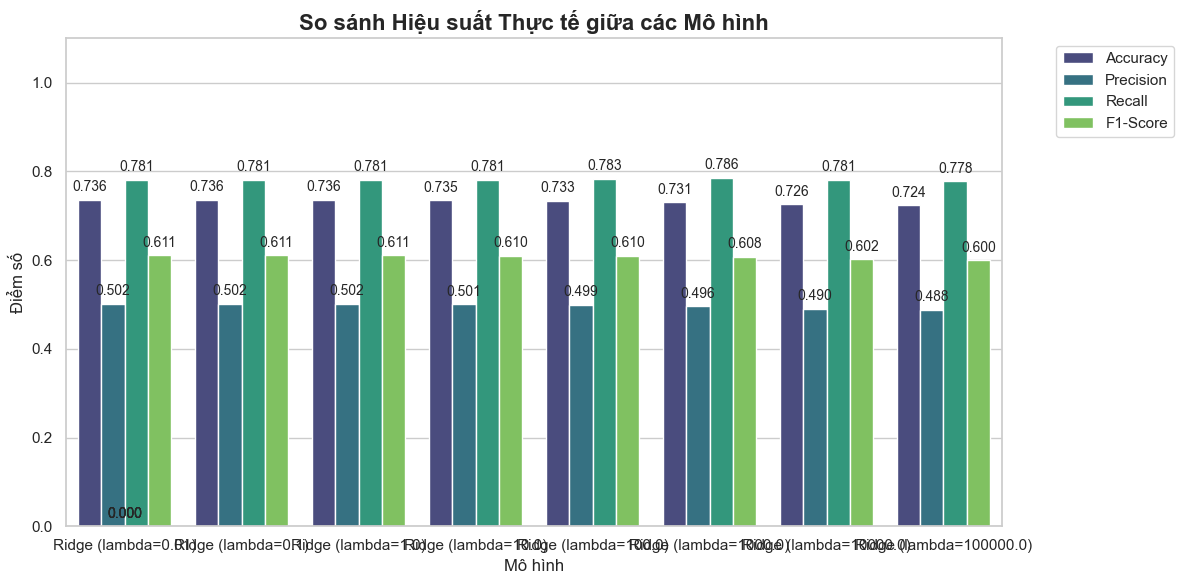

In [16]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}

lambda_value = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,10000.0, 100000.0]
for lam in lambda_value:
    model_ridge = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l2', lambda_param=lam)
    model_ridge.fit(X_train_resampled_np.astype(float), y_train_resampled_np.astype(float))
    y_pred_ridge = model_ridge.predict(X_test.values.astype(float))
    save_model_results(model_results, f'Ridge (lambda={lam})', y_test.values, y_pred_ridge)
create_comparison_table(model_results)

Đã lưu kết quả cho Lasso (lambda=0.01)
Đã lưu kết quả cho Lasso (lambda=0.1)
Đã lưu kết quả cho Lasso (lambda=1.0)
Đã lưu kết quả cho Lasso (lambda=10.0)
Đã lưu kết quả cho Lasso (lambda=100.0)
Đã lưu kết quả cho Lasso (lambda=1000.0)
Đã lưu kết quả cho Lasso (lambda=10000.0)
Đã lưu kết quả cho Lasso (lambda=100000.0)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Lasso (lambda=0.01),0.7356,0.5017,0.7807,0.6109
1,Lasso (lambda=0.1),0.7356,0.5017,0.7807,0.6109
2,Lasso (lambda=1.0),0.7349,0.5009,0.7807,0.6102
3,Lasso (lambda=10.0),0.7335,0.4991,0.7781,0.6082
4,Lasso (lambda=100.0),0.7321,0.4975,0.7834,0.6085
5,Lasso (lambda=1000.0),0.6382,0.4040,0.7594,0.5274
6,Lasso (lambda=10000.0),0.4648,0.2929,0.7166,0.4158
7,Lasso (lambda=100000.0),0.5430,0.2827,0.4679,0.3525


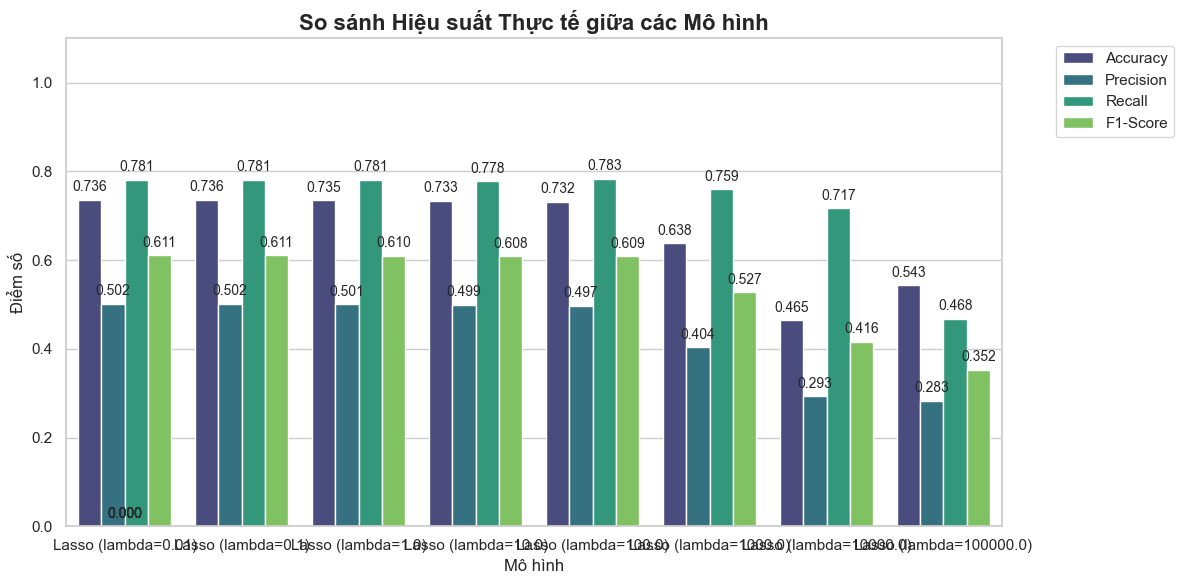

In [17]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}

lambda_value = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,10000.0, 100000.0]
for lam in lambda_value:
    model_lasso = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l1', lambda_param=lam)
    model_lasso.fit(X_train_resampled_np.astype(float), y_train_resampled_np.astype(float))
    y_pred_lasso = model_lasso.predict(X_test.values.astype(float))
    save_model_results(model_results, f'Lasso (lambda={lam})', y_test.values, y_pred_lasso)
create_comparison_table(model_results)

In [18]:


model_standard = CustomLogisticRegression(learning_rate = 0.01, num_iterations = 2000, penalty = 'none')
model_ridge = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l2', lambda_param=1000.0)
model_lasso = CustomLogisticRegression(learning_rate=0.01, num_iterations=2000, penalty='l1', lambda_param=100.0)



Đã lưu kết quả cho Logistic Regression Chuẩn
Đã lưu kết quả cho Logistic Regression Ridge
Đã lưu kết quả cho Logistic Regression Lasso
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression Chuẩn,0.7356,0.5017,0.7807,0.6109
1,Logistic Regression Ridge,0.7306,0.4958,0.7861,0.6081
2,Logistic Regression Lasso,0.7321,0.4975,0.7834,0.6085


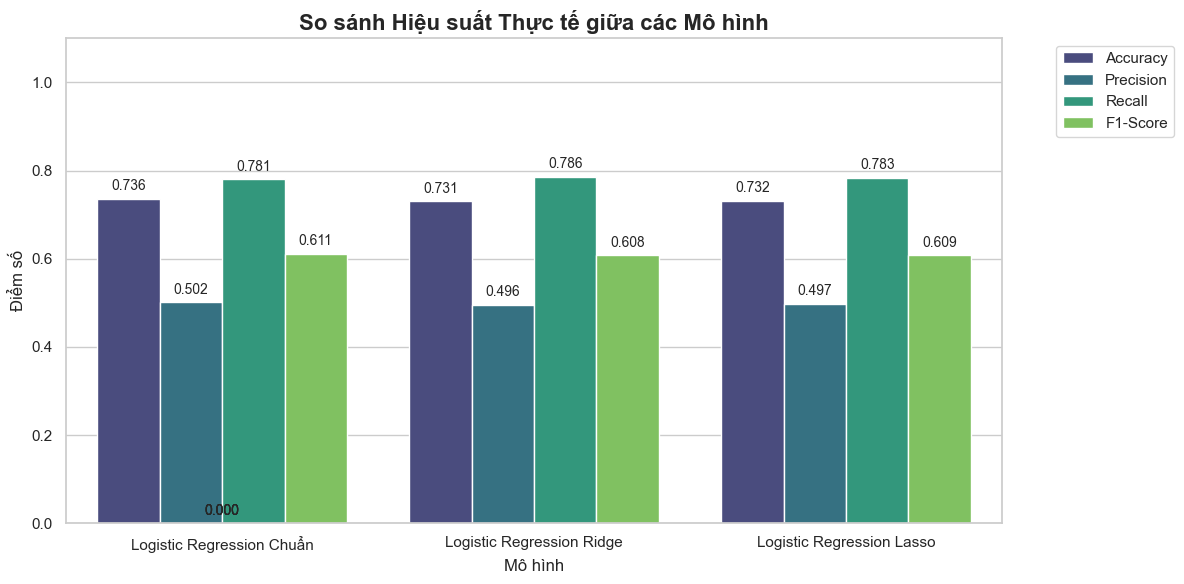

In [19]:
LR_model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [] 
}


model_standard.fit(X_train_resampled.values.astype(float), y_train_resampled.values.astype(float))
y_pred_standard = model_standard.predict(X_test.values.astype(float))
save_model_results(LR_model_results,"Logistic Regression Chuẩn", y_test.values, y_pred_standard)

model_ridge.fit(X_train_resampled.values.astype(float), y_train_resampled.values.astype(float))
y_pred_ridge = model_ridge.predict(X_test.values.astype(float))
save_model_results(LR_model_results,"Logistic Regression Ridge", y_test.values, y_pred_ridge)

model_lasso.fit(X_train_resampled.values.astype(float), y_train_resampled.values.astype(float))
y_pred_lasso = model_lasso.predict(X_test.values.astype(float))
save_model_results(LR_model_results,"Logistic Regression Lasso", y_test.values, y_pred_lasso)

create_comparison_table(LR_model_results)

In [20]:
from KNN import CustomKNN

Đã lưu kết quả cho KNN (k=1) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=2) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=3) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=4) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=5) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=6) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=7) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=8) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=9) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=10) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=11) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=12) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=13) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=14) (p=2) (uniform)
Đã lưu kết quả cho KNN (k=15) (p=2) (uniform)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=2) (uniform),0.7207,0.4792,0.5856,0.5271
1,KNN (k=2) (p=2) (uniform),0.7456,0.5237,0.4733,0.4972
2,KNN (k=3) (p=2) (uniform),0.7036,0.4619,0.6979,0.5559
3,KNN (k=4) (p=2) (uniform),0.7242,0.4850,0.6070,0.5392
4,KNN (k=5) (p=2) (uniform),0.6866,0.4443,0.7139,0.5477
5,KNN (k=6) (p=2) (uniform),0.7178,0.4780,0.6684,0.5574
6,KNN (k=7) (p=2) (uniform),0.6851,0.4446,0.7406,0.5557
7,KNN (k=8) (p=2) (uniform),0.7129,0.4737,0.7219,0.5720
8,KNN (k=9) (p=2) (uniform),0.6851,0.4472,0.7807,0.5686
9,KNN (k=10) (p=2) (uniform),0.7079,0.4689,0.7460,0.5759


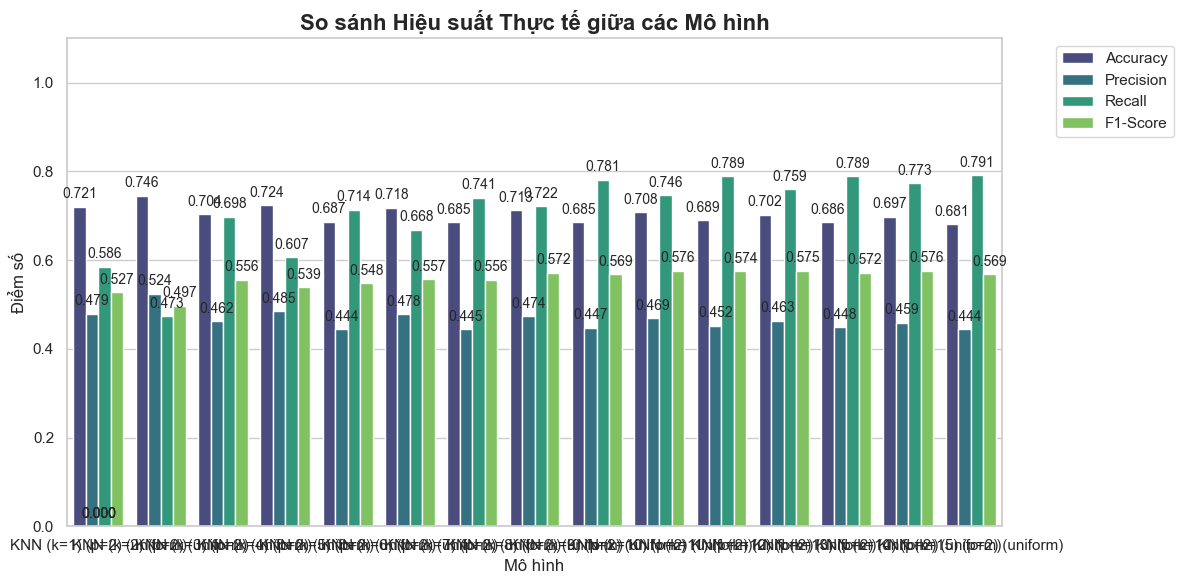

In [21]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k)
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=2) (uniform)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [22]:
Knn_model_results = {
    'Mô hình': [model_results['Mô hình'][9]],
    'Accuracy': [model_results['Accuracy'][9]],
    'Precision': [model_results['Precision'][9]],
    'Recall': [model_results['Recall'][9]],
    'F1-Score': [model_results['F1-Score'][9]]
}

Đã lưu kết quả cho KNN (k=1) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=2) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=3) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=4) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=5) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=6) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=7) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=8) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=9) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=10) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=11) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=12) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=13) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=14) (p=1) (uniform)
Đã lưu kết quả cho KNN (k=15) (p=1) (uniform)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=1) (uniform),0.7356,0.5024,0.5668,0.5327
1,KNN (k=2) (p=1) (uniform),0.7427,0.5192,0.4332,0.4723
2,KNN (k=3) (p=1) (uniform),0.7207,0.4812,0.6497,0.5529
3,KNN (k=4) (p=1) (uniform),0.7484,0.5244,0.5749,0.5485
4,KNN (k=5) (p=1) (uniform),0.7178,0.4786,0.6872,0.5642
5,KNN (k=6) (p=1) (uniform),0.7356,0.5021,0.6257,0.5571
6,KNN (k=7) (p=1) (uniform),0.7143,0.4752,0.7166,0.5714
7,KNN (k=8) (p=1) (uniform),0.7335,0.4990,0.6818,0.5763
8,KNN (k=9) (p=1) (uniform),0.7178,0.4801,0.7433,0.5834
9,KNN (k=10) (p=1) (uniform),0.7370,0.5038,0.7166,0.5916


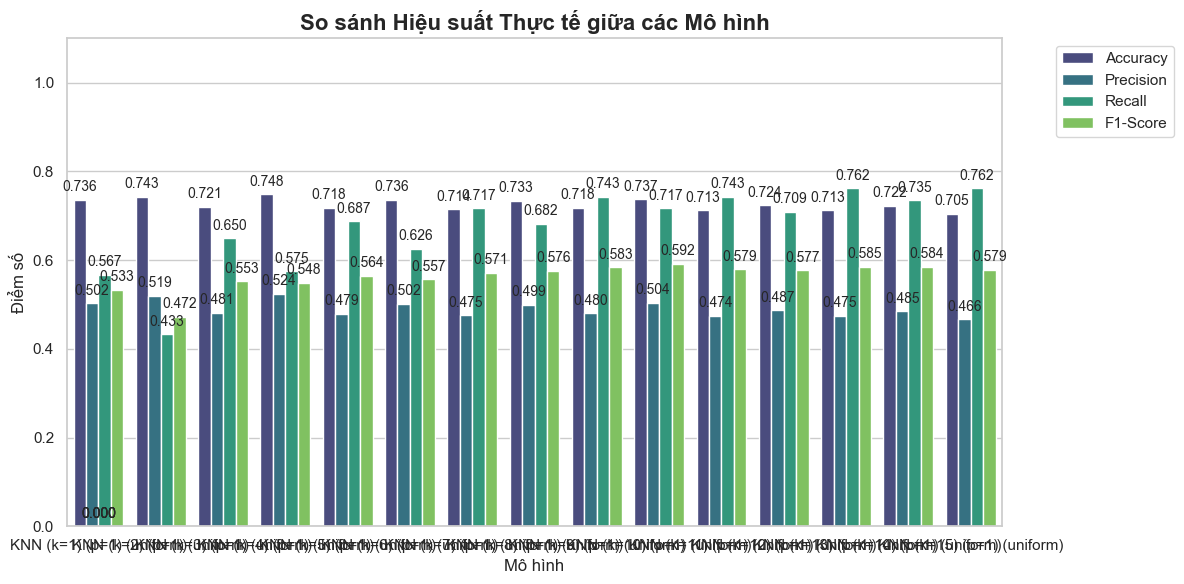

In [23]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p=1)
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=1) (uniform)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [24]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][14])

Đã lưu kết quả cho KNN (k=1) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=2) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=3) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=4) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=5) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=6) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=7) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=8) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=9) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=10) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=11) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=12) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=13) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=14) (p=mahalanobis) (uniform)
Đã lưu kết quả cho KNN (k=15) (p=mahalanobis) (uniform)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=mahalanobis) (uniform),0.7036,0.4549,0.5802,0.5100
1,KNN (k=2) (p=mahalanobis) (uniform),0.7164,0.4679,0.4866,0.4771
2,KNN (k=3) (p=mahalanobis) (uniform),0.6851,0.4416,0.6979,0.5409
3,KNN (k=4) (p=mahalanobis) (uniform),0.7093,0.4645,0.6123,0.5283
4,KNN (k=5) (p=mahalanobis) (uniform),0.6823,0.4416,0.7380,0.5526
5,KNN (k=6) (p=mahalanobis) (uniform),0.7008,0.4577,0.6791,0.5468
6,KNN (k=7) (p=mahalanobis) (uniform),0.6823,0.4432,0.7620,0.5605
7,KNN (k=8) (p=mahalanobis) (uniform),0.7001,0.4597,0.7326,0.5649
8,KNN (k=9) (p=mahalanobis) (uniform),0.6745,0.4373,0.7834,0.5613
9,KNN (k=10) (p=mahalanobis) (uniform),0.6972,0.4578,0.7540,0.5697


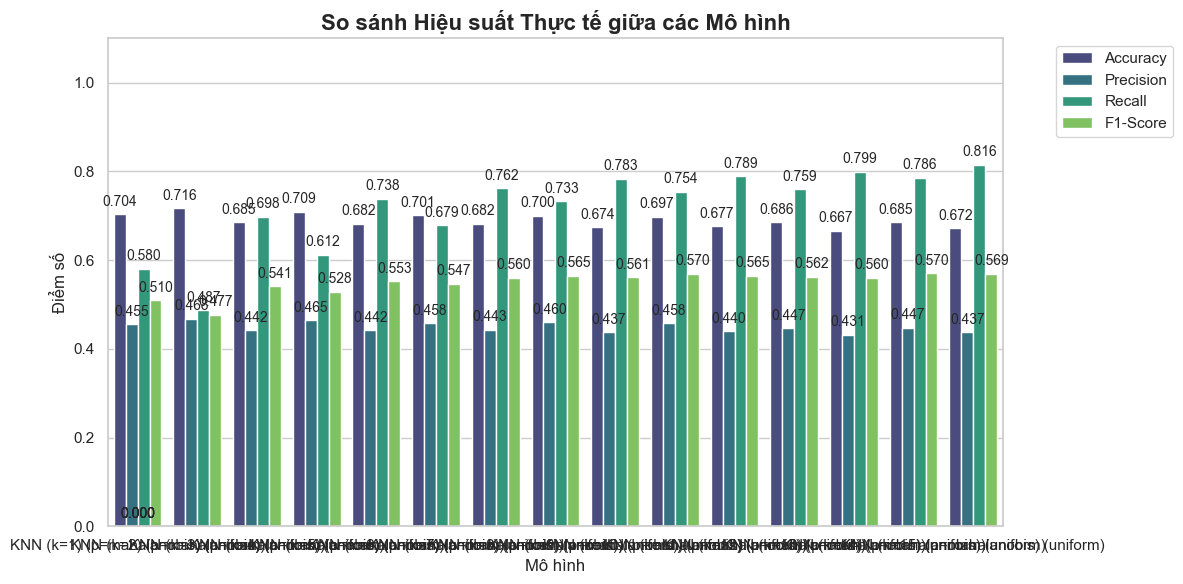

In [25]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p='mahalanobis')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=mahalanobis) (uniform)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [26]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][13])

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=10) (p=2) (uniform),0.7079,0.4689,0.7460,0.5759
1,KNN (k=15) (p=1) (uniform),0.7050,0.4664,0.7620,0.5787
2,KNN (k=14) (p=mahalanobis) (uniform),0.6851,0.4475,0.7861,0.5703


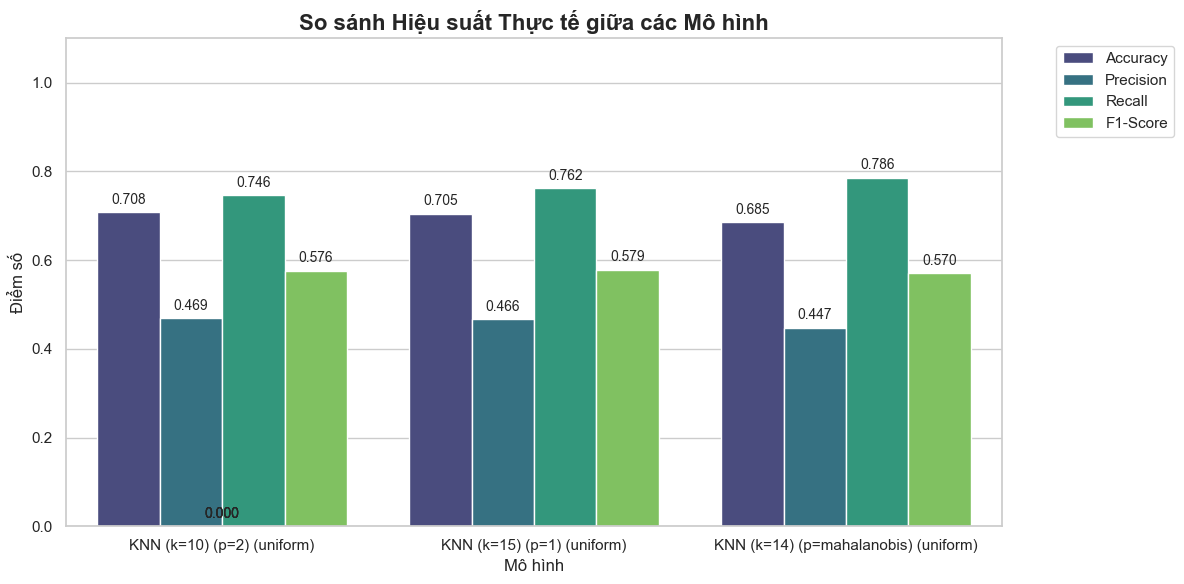

In [27]:
create_comparison_table(Knn_model_results)

Đã lưu kết quả cho KNN (k=1) (p=2) (distance)
Đã lưu kết quả cho KNN (k=2) (p=2) (distance)
Đã lưu kết quả cho KNN (k=3) (p=2) (distance)
Đã lưu kết quả cho KNN (k=4) (p=2) (distance)
Đã lưu kết quả cho KNN (k=5) (p=2) (distance)
Đã lưu kết quả cho KNN (k=6) (p=2) (distance)
Đã lưu kết quả cho KNN (k=7) (p=2) (distance)
Đã lưu kết quả cho KNN (k=8) (p=2) (distance)
Đã lưu kết quả cho KNN (k=9) (p=2) (distance)
Đã lưu kết quả cho KNN (k=10) (p=2) (distance)
Đã lưu kết quả cho KNN (k=11) (p=2) (distance)
Đã lưu kết quả cho KNN (k=12) (p=2) (distance)
Đã lưu kết quả cho KNN (k=13) (p=2) (distance)
Đã lưu kết quả cho KNN (k=14) (p=2) (distance)
Đã lưu kết quả cho KNN (k=15) (p=2) (distance)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=2) (distance),0.7207,0.4792,0.5856,0.5271
1,KNN (k=2) (p=2) (distance),0.7193,0.4768,0.5775,0.5224
2,KNN (k=3) (p=2) (distance),0.7043,0.4598,0.6417,0.5357
3,KNN (k=4) (p=2) (distance),0.7058,0.4606,0.6257,0.5306
4,KNN (k=5) (p=2) (distance),0.6951,0.4503,0.6658,0.5372
5,KNN (k=6) (p=2) (distance),0.7050,0.4625,0.6765,0.5494
6,KNN (k=7) (p=2) (distance),0.6951,0.4525,0.7005,0.5498
7,KNN (k=8) (p=2) (distance),0.6923,0.4497,0.7059,0.5494
8,KNN (k=9) (p=2) (distance),0.6873,0.4455,0.7219,0.5510
9,KNN (k=10) (p=2) (distance),0.6958,0.4539,0.7112,0.5542


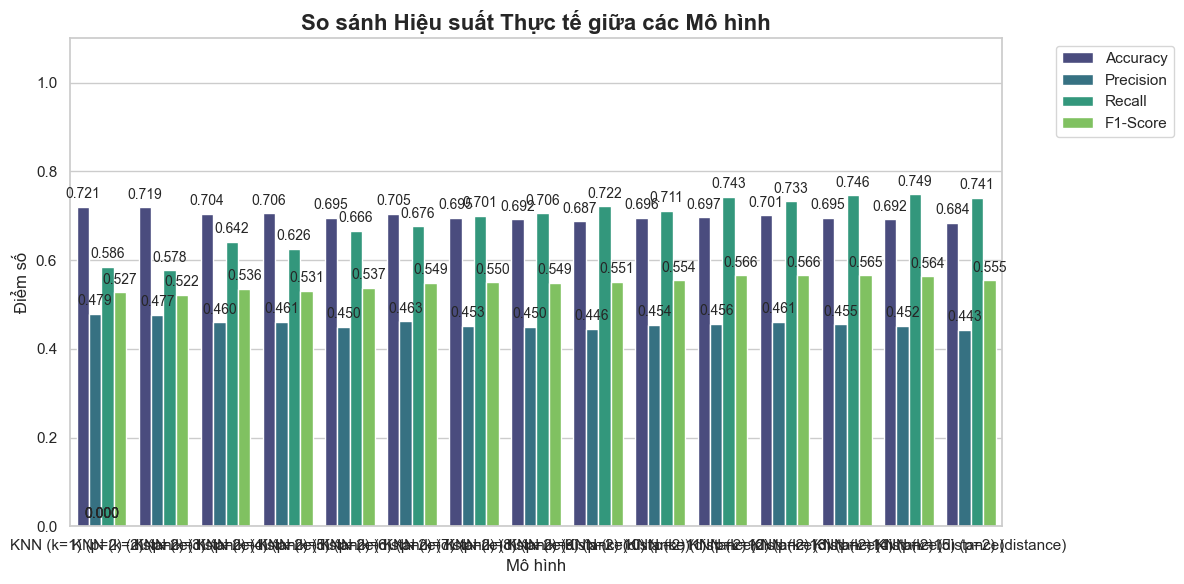

In [28]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p=2, weights='distance')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=2) (distance)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [29]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][13])

Đã lưu kết quả cho KNN (k=1) (p=1) (distance)
Đã lưu kết quả cho KNN (k=2) (p=1) (distance)
Đã lưu kết quả cho KNN (k=3) (p=1) (distance)
Đã lưu kết quả cho KNN (k=4) (p=1) (distance)
Đã lưu kết quả cho KNN (k=5) (p=1) (distance)
Đã lưu kết quả cho KNN (k=6) (p=1) (distance)
Đã lưu kết quả cho KNN (k=7) (p=1) (distance)
Đã lưu kết quả cho KNN (k=8) (p=1) (distance)
Đã lưu kết quả cho KNN (k=9) (p=1) (distance)
Đã lưu kết quả cho KNN (k=10) (p=1) (distance)
Đã lưu kết quả cho KNN (k=11) (p=1) (distance)
Đã lưu kết quả cho KNN (k=12) (p=1) (distance)
Đã lưu kết quả cho KNN (k=13) (p=1) (distance)
Đã lưu kết quả cho KNN (k=14) (p=1) (distance)
Đã lưu kết quả cho KNN (k=15) (p=1) (distance)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=1) (distance),0.7356,0.5024,0.5668,0.5327
1,KNN (k=2) (p=1) (distance),0.7363,0.5036,0.5668,0.5333
2,KNN (k=3) (p=1) (distance),0.7214,0.4807,0.5989,0.5333
3,KNN (k=4) (p=1) (distance),0.7321,0.4967,0.6070,0.5463
4,KNN (k=5) (p=1) (distance),0.7242,0.4857,0.6364,0.5509
5,KNN (k=6) (p=1) (distance),0.7264,0.4888,0.6417,0.5549
6,KNN (k=7) (p=1) (distance),0.7228,0.4846,0.6738,0.5638
7,KNN (k=8) (p=1) (distance),0.7299,0.4942,0.6845,0.5740
8,KNN (k=9) (p=1) (distance),0.7221,0.4839,0.6818,0.5660
9,KNN (k=10) (p=1) (distance),0.7228,0.4849,0.6872,0.5686


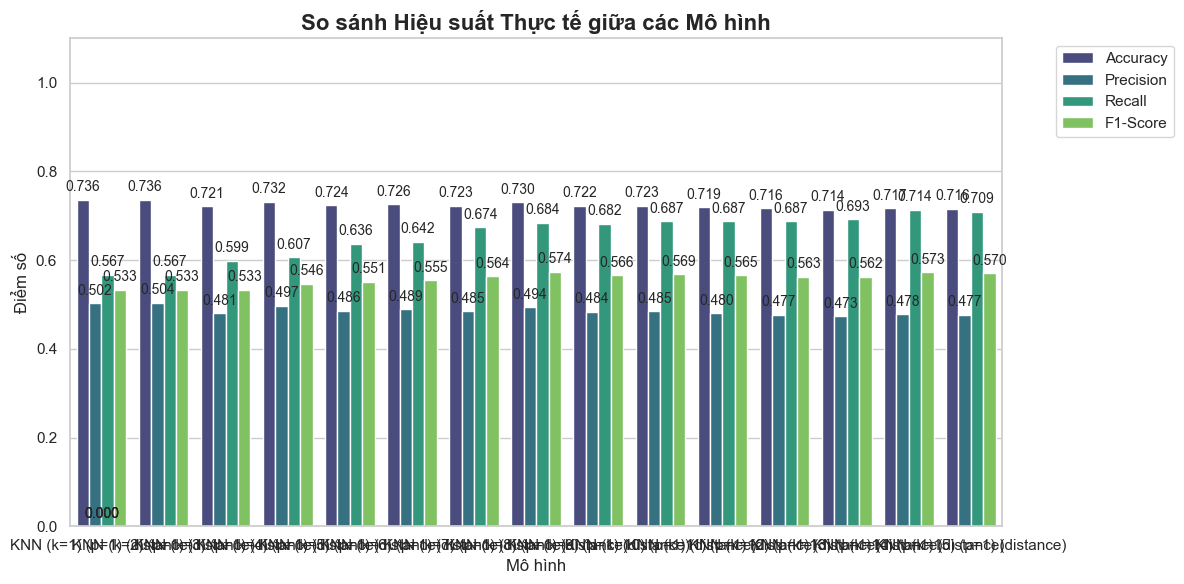

In [30]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p=1, weights='distance')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=1) (distance)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [31]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][13])

Đã lưu kết quả cho KNN (k=1) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=2) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=3) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=4) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=5) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=6) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=7) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=8) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=9) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=10) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=11) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=12) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=13) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=14) (p=mahalanobis) (distance)
Đã lưu kết quả cho KNN (k=15) (p=mahalanobis) (distance)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=1) (p=mahalanobis) (distance),0.7036,0.4549,0.5802,0.5100
1,KNN (k=2) (p=mahalanobis) (distance),0.7058,0.4578,0.5802,0.5118
2,KNN (k=3) (p=mahalanobis) (distance),0.6795,0.4326,0.6604,0.5228
3,KNN (k=4) (p=mahalanobis) (distance),0.6887,0.4424,0.6578,0.5290
4,KNN (k=5) (p=mahalanobis) (distance),0.6809,0.4368,0.6925,0.5357
5,KNN (k=6) (p=mahalanobis) (distance),0.6859,0.4426,0.7005,0.5424
6,KNN (k=7) (p=mahalanobis) (distance),0.6766,0.4337,0.7086,0.5381
7,KNN (k=8) (p=mahalanobis) (distance),0.6830,0.4419,0.7326,0.5513
8,KNN (k=9) (p=mahalanobis) (distance),0.6809,0.4411,0.7513,0.5559
9,KNN (k=10) (p=mahalanobis) (distance),0.6795,0.4396,0.7487,0.5539


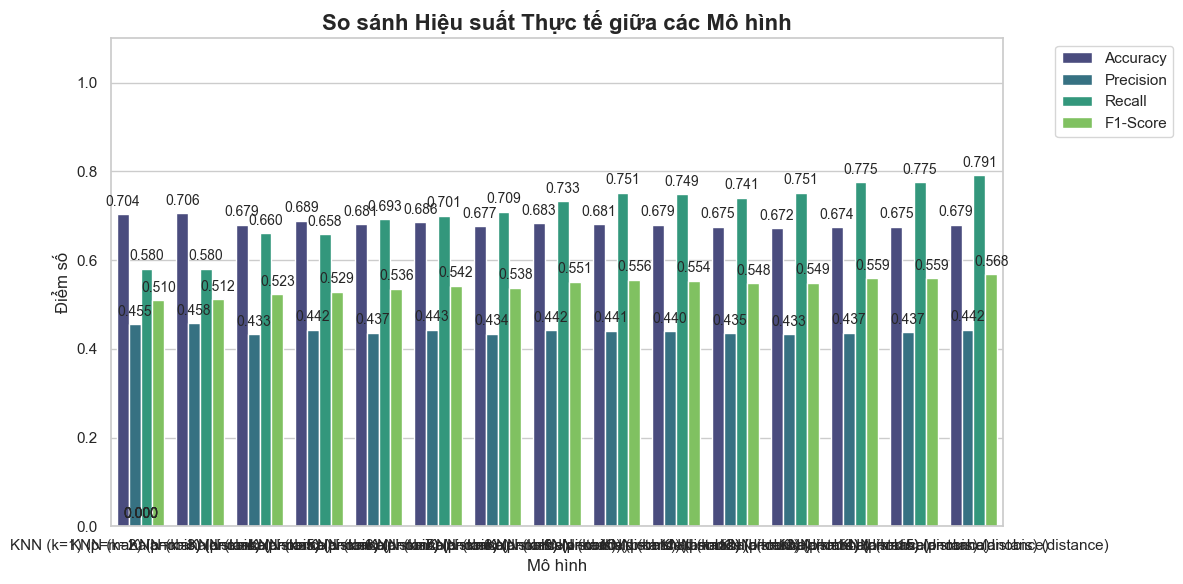

In [32]:
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
k_num = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
for k in k_num:
    knn_standard = CustomKNN(k=k, p='mahalanobis', weights='distance')
    knn_standard.fit(X_train_resampled.values, y_train_resampled.values)
    y_pred_knn = knn_standard.predict(X_test.values)
    save_model_results(model_results, f'KNN (k={k}) (p=mahalanobis) (distance)', y_test.values, y_pred_knn)
create_comparison_table(model_results)

In [33]:
for key in model_results:
    Knn_model_results[key].append(model_results[key][12])

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,KNN (k=10) (p=2) (uniform),0.7079,0.4689,0.7460,0.5759
1,KNN (k=15) (p=1) (uniform),0.7050,0.4664,0.7620,0.5787
2,KNN (k=14) (p=mahalanobis) (uniform),0.6851,0.4475,0.7861,0.5703
3,KNN (k=14) (p=2) (distance),0.6923,0.4523,0.7487,0.5639
4,KNN (k=14) (p=1) (distance),0.7171,0.4785,0.7139,0.5730
5,KNN (k=13) (p=mahalanobis) (distance),0.6745,0.4367,0.7754,0.5588


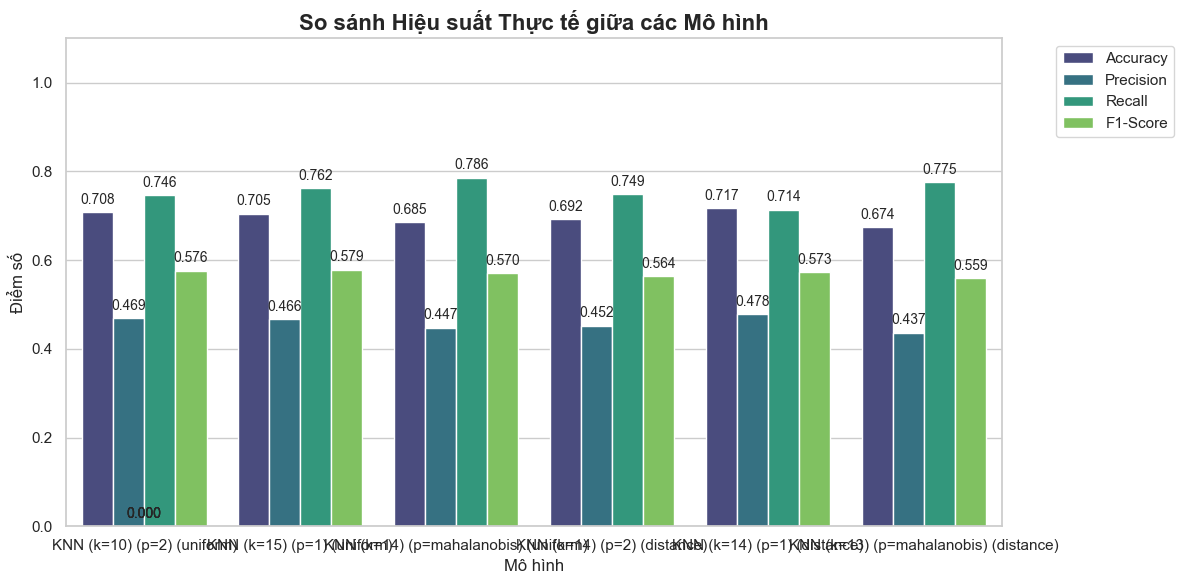

In [34]:
create_comparison_table(Knn_model_results)

In [2]:
import pickle
with open('results/train_test_data.pkl', 'rb') as f:
    X_train_resampled, X_test, y_train_resampled, y_test = pickle.load(f) 

Đã lưu kết quả cho Decision Tree (Gini) (max_depth=5)
Đã lưu kết quả cho Decision Tree (Gini) (max_depth=10)
Đã lưu kết quả cho Decision Tree (Gini) (max_depth=15)
Đã lưu kết quả cho Decision Tree (Gini) (max_depth=20)
Đã lưu kết quả cho Decision Tree (Gini) (max_depth=25)
Đã lưu kết quả cho Decision Tree (Gini) (max_depth=28)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Gini) (max_depth=5),0.7484,0.5192,0.7246,0.6049
1,Decision Tree (Gini) (max_depth=10),0.7292,0.4927,0.6283,0.5523
2,Decision Tree (Gini) (max_depth=15),0.7249,0.4861,0.6096,0.5409
3,Decision Tree (Gini) (max_depth=20),0.7328,0.4977,0.5882,0.5392
4,Decision Tree (Gini) (max_depth=25),0.7321,0.4965,0.5722,0.5317
5,Decision Tree (Gini) (max_depth=28),0.7321,0.4965,0.5695,0.5305


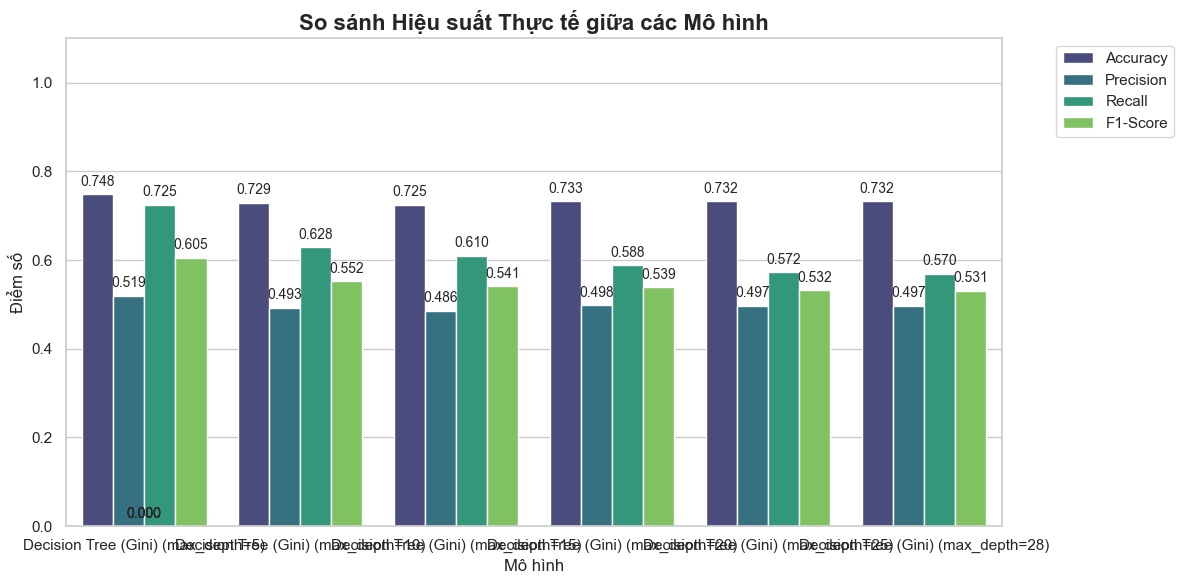

In [20]:
from Decision_Tree import DecisionTree
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for max_depth in [5,10,15,20,25,28]:
    gini_model = DecisionTree(max_depth=max_depth, criterion='gini')
    gini_model.fit(X_train_resampled, y_train_resampled)
    y_pred_gini = gini_model.predict(X_test.values)
    save_model_results(model_results, f'Decision Tree (Gini) (max_depth={max_depth})', y_test.values, y_pred_gini)


create_comparison_table(model_results)

In [21]:
decision_model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

In [22]:
for key in decision_model_results:
    decision_model_results[key].append(model_results[key][0])

Đã lưu kết quả cho Decision Tree (Entropy) (max_depth=5)
Đã lưu kết quả cho Decision Tree (Entropy) (max_depth=10)
Đã lưu kết quả cho Decision Tree (Entropy) (max_depth=15)
Đã lưu kết quả cho Decision Tree (Entropy) (max_depth=20)
Đã lưu kết quả cho Decision Tree (Entropy) (max_depth=25)
Đã lưu kết quả cho Decision Tree (Entropy) (max_depth=28)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Entropy) (max_depth=5),0.7385,0.5054,0.7567,0.6060
1,Decision Tree (Entropy) (max_depth=10),0.7406,0.5088,0.6925,0.5866
2,Decision Tree (Entropy) (max_depth=15),0.7399,0.5096,0.5668,0.5367
3,Decision Tree (Entropy) (max_depth=20),0.7349,0.5012,0.5775,0.5366
4,Decision Tree (Entropy) (max_depth=25),0.7356,0.5023,0.5775,0.5373
5,Decision Tree (Entropy) (max_depth=28),0.7356,0.5024,0.5695,0.5338


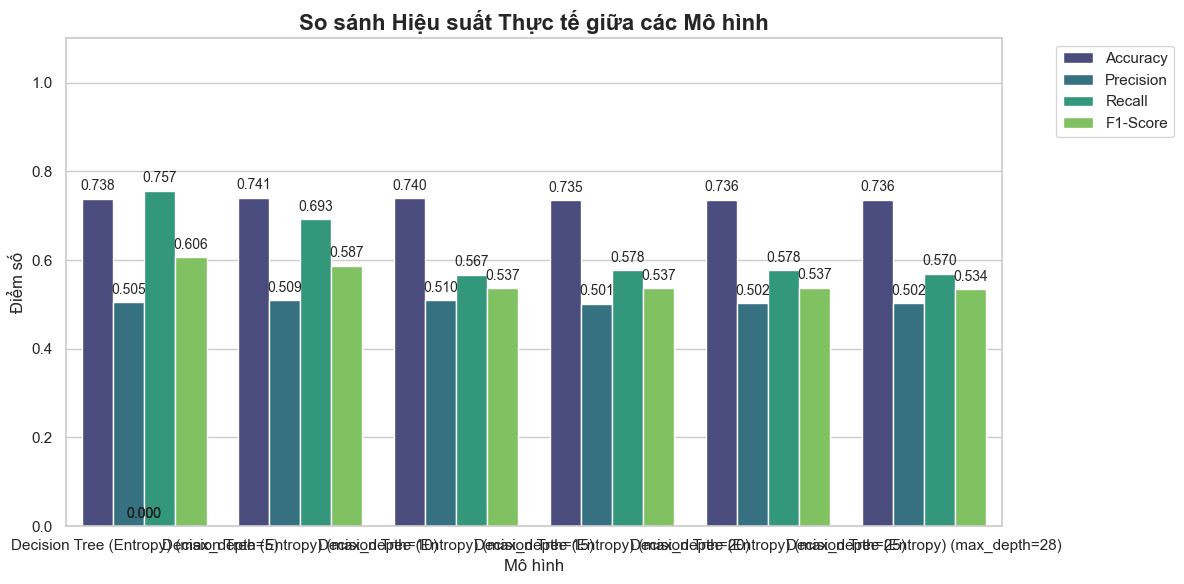

In [23]:
from Decision_Tree import DecisionTree
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for max_depth in [5,10,15,20,25,28]:
    entropy_model = DecisionTree(max_depth=max_depth, criterion='entropy')
    entropy_model.fit(X_train_resampled, y_train_resampled)
    y_pred_entropy = entropy_model.predict(X_test.values)
    save_model_results(model_results, f'Decision Tree (Entropy) (max_depth={max_depth})', y_test.values, y_pred_entropy)


create_comparison_table(model_results)

In [24]:
for key in decision_model_results:
    decision_model_results[key].append(model_results[key][0])

Đã lưu kết quả cho Decision Tree (Ratio) (max_depth=5)
Đã lưu kết quả cho Decision Tree (Ratio) (max_depth=10)
Đã lưu kết quả cho Decision Tree (Ratio) (max_depth=15)
Đã lưu kết quả cho Decision Tree (Ratio) (max_depth=20)
Đã lưu kết quả cho Decision Tree (Ratio) (max_depth=25)
Đã lưu kết quả cho Decision Tree (Ratio) (max_depth=28)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Ratio) (max_depth=5),0.6311,0.4086,0.8663,0.5553
1,Decision Tree (Ratio) (max_depth=10),0.6809,0.4454,0.8182,0.5768
2,Decision Tree (Ratio) (max_depth=15),0.7335,0.4990,0.6684,0.5714
3,Decision Tree (Ratio) (max_depth=20),0.7335,0.4990,0.6631,0.5695
4,Decision Tree (Ratio) (max_depth=25),0.7406,0.5101,0.6070,0.5543
5,Decision Tree (Ratio) (max_depth=28),0.7413,0.5115,0.5936,0.5495


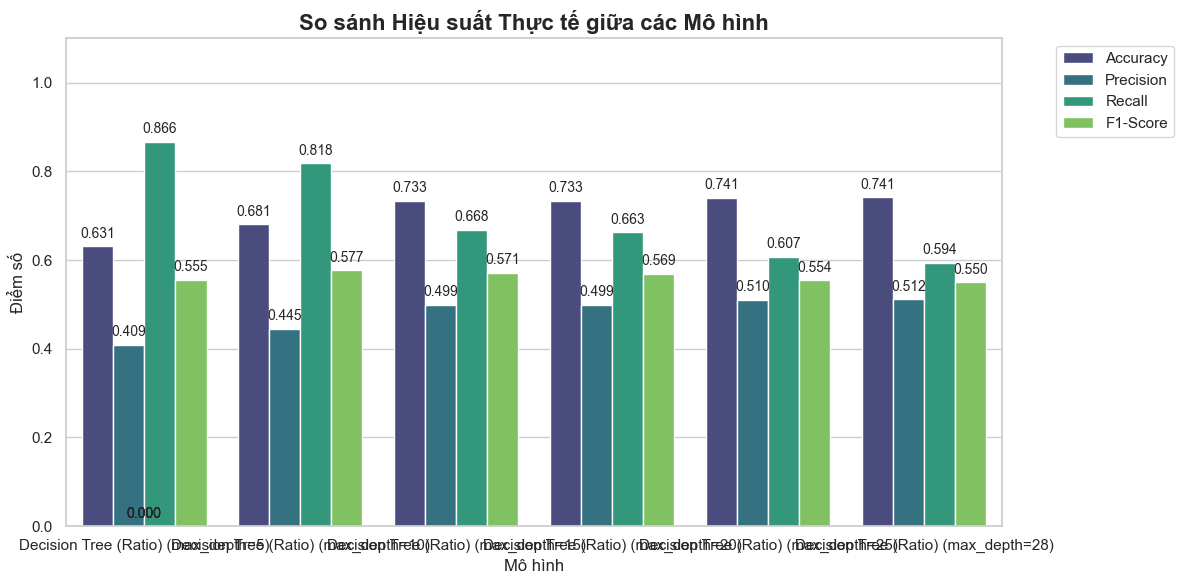

In [25]:
from Decision_Tree import DecisionTree
model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for max_depth in [5,10,15,20,25,28]:
    ratio_model = DecisionTree(max_depth=max_depth, criterion='ratio')
    ratio_model.fit(X_train_resampled, y_train_resampled)
    y_pred_ratio = ratio_model.predict(X_test.values)
    save_model_results(model_results, f'Decision Tree (Ratio) (max_depth={max_depth})', y_test.values, y_pred_ratio)


create_comparison_table(model_results)

In [26]:
for key in decision_model_results:
    decision_model_results[key].append(model_results[key][1])

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Gini) (max_depth=5),0.7484,0.5192,0.7246,0.6049
1,Decision Tree (Entropy) (max_depth=5),0.7385,0.5054,0.7567,0.6060
2,Decision Tree (Ratio) (max_depth=10),0.6809,0.4454,0.8182,0.5768


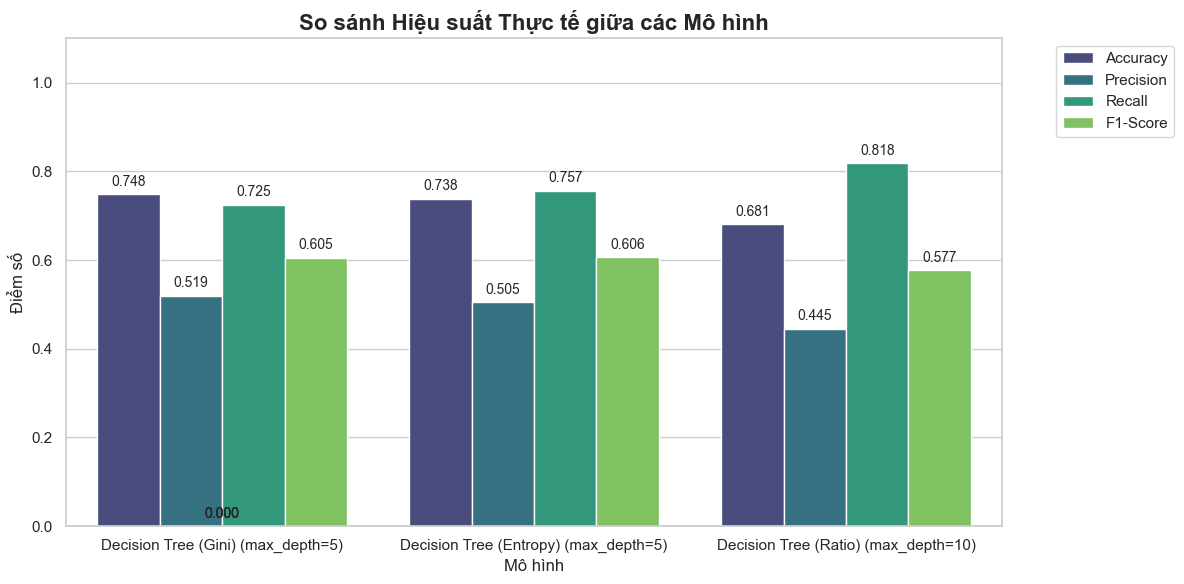

In [27]:
create_comparison_table(decision_model_results)

Đã lưu kết quả cho Random Forest (criterion=gini)
Đã lưu kết quả cho Random Forest (criterion=entropy)
Đã lưu kết quả cho Random Forest (criterion=ratio)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Random Forest (criterion=gini),0.7612,0.5352,0.7727,0.6324
1,Random Forest (criterion=entropy),0.7484,0.5182,0.7594,0.6161
2,Random Forest (criterion=ratio),0.7200,0.4837,0.7914,0.6004


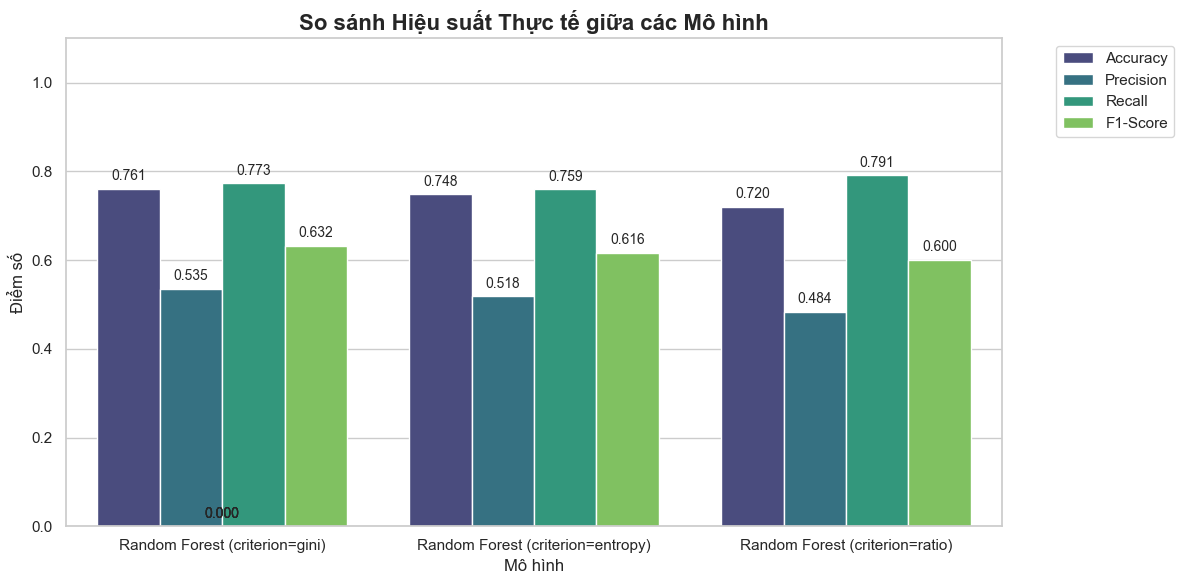

In [38]:
from RandomForest import RandomForest

model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for criterion in ['gini', 'entropy', 'ratio']:
        rf_model = RandomForest(n_trees=100, max_depth=10, criterion=criterion)
        rf_model.fit(X_train_resampled, y_train_resampled)
        y_pred_rf = rf_model.predict(X_test.values)
        save_model_results(model_results, f'Random Forest (criterion={criterion})', y_test.values, y_pred_rf)

create_comparison_table(model_results)

In [50]:
with open('results/best_model_results.pkl', 'rb') as f:
    best_model_results = pickle.load(f)

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression Lasso,0.7321,0.4975,0.7834,0.6085
1,KNN (k=14) (p=mahalanobis) (uniform),0.6851,0.4475,0.7861,0.5703
2,Random Forest (criterion=gini),0.7612,0.5352,0.7727,0.6324
3,Decision Tree (Entropy) (max_depth=5),0.7385,0.5054,0.7567,0.6060


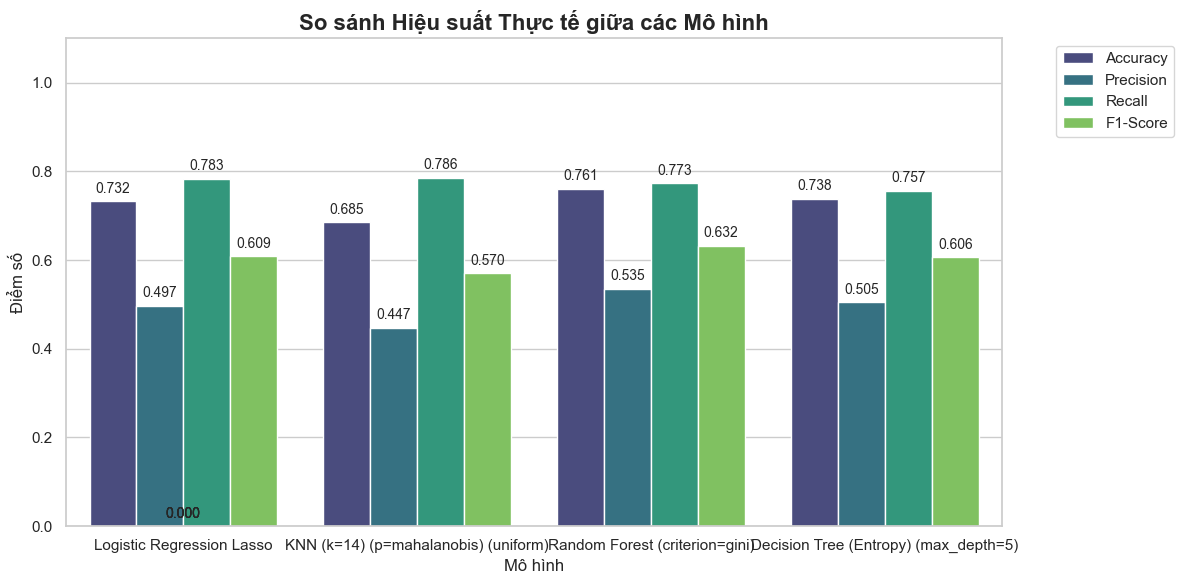

In [51]:
create_comparison_table(best_model_results)

In [4]:
import pickle

In [5]:
with open('results/train_test_data.pkl', 'rb') as f:
    X_train_resampled, X_test, y_train_resampled, y_test = pickle.load(f)

In [7]:
display(X_train_resampled.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1.321816,0.981556,1.6599,True,True,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,-0.26741,-0.971546,-0.562252,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1.444064,0.837066,1.756104,True,False,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
3,0,-1.204646,0.641092,-0.908326,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
4,0,0.669826,-0.808787,-0.101561,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [17]:
import importlib
import CustomLinearSVM


importlib.reload(CustomLinearSVM)



<module 'CustomLinearSVM' from 'c:\\Users\\LENOVO\\Downloads\\khu lap trinh\\machine_learning\\project\\CustomLinearSVM.py'>

In [18]:
from CustomLinearSVM import CustomLinearSVM

Đã lưu kết quả cho Linear SVM (lr=0.0001, lambda=0.001)
Đã lưu kết quả cho Linear SVM (lr=0.0001, lambda=0.01)
Đã lưu kết quả cho Linear SVM (lr=0.0001, lambda=0.1)
Đã lưu kết quả cho Linear SVM (lr=0.0001, lambda=1.0)
Đã lưu kết quả cho Linear SVM (lr=0.0001, lambda=10.0)
Đã lưu kết quả cho Linear SVM (lr=0.001, lambda=0.001)
Đã lưu kết quả cho Linear SVM (lr=0.001, lambda=0.01)
Đã lưu kết quả cho Linear SVM (lr=0.001, lambda=0.1)
Đã lưu kết quả cho Linear SVM (lr=0.001, lambda=1.0)
Đã lưu kết quả cho Linear SVM (lr=0.001, lambda=10.0)
Đã lưu kết quả cho Linear SVM (lr=0.01, lambda=0.001)
Đã lưu kết quả cho Linear SVM (lr=0.01, lambda=0.01)
Đã lưu kết quả cho Linear SVM (lr=0.01, lambda=0.1)
Đã lưu kết quả cho Linear SVM (lr=0.01, lambda=1.0)
Đã lưu kết quả cho Linear SVM (lr=0.01, lambda=10.0)
Đã lưu kết quả cho Linear SVM (lr=0.1, lambda=0.001)
Đã lưu kết quả cho Linear SVM (lr=0.1, lambda=0.01)
Đã lưu kết quả cho Linear SVM (lr=0.1, lambda=0.1)
Đã lưu kết quả cho Linear SVM (lr=0.1

,Mô hình,Accuracy,Precision,Recall,F1-Score
0,"Linear SVM (lr=0.0001, lambda=0.001)",0.6944,0.4585,0.8262,0.5897
1,"Linear SVM (lr=0.0001, lambda=0.01)",0.6859,0.4517,0.8503,0.5900
2,"Linear SVM (lr=0.0001, lambda=0.1)",0.6503,0.4249,0.8930,0.5759
3,"Linear SVM (lr=0.0001, lambda=1.0)",0.3539,0.2912,0.9973,0.4508
4,"Linear SVM (lr=0.0001, lambda=10.0)",0.3021,0.2758,1.0000,0.4324
5,"Linear SVM (lr=0.001, lambda=0.001)",0.4072,0.3090,0.9947,0.4715
6,"Linear SVM (lr=0.001, lambda=0.01)",0.3070,0.2769,0.9973,0.4335
7,"Linear SVM (lr=0.001, lambda=0.1)",0.2658,0.2658,1.0000,0.4200
8,"Linear SVM (lr=0.001, lambda=1.0)",0.2658,0.2658,1.0000,0.4200
9,"Linear SVM (lr=0.001, lambda=10.0)",0.2658,0.2658,1.0000,0.4200


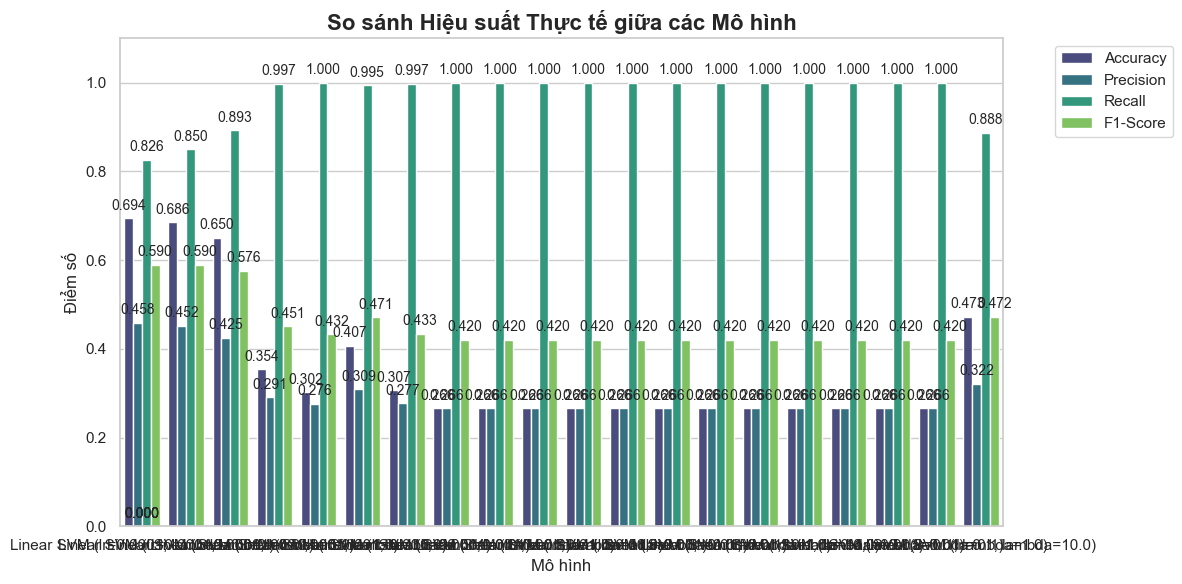

In [ ]:
SVM_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for learning_rate in [0.0001]:
    for lambda_param in [0.001, 0.01, 0.1, 1.0, 10.0]:
        svm_model = CustomLinearSVM(learning_rate=learning_rate, lambda_param=lambda_param)
        svm_model.fit(X_train_resampled, y_train_resampled)
        y_pred_svm = svm_model.predict(X_test)
        save_model_results(SVM_results, f'Linear SVM (lr={learning_rate}, lambda={lambda_param})', y_test.values, y_pred_svm)
create_comparison_table(SVM_results)

In [20]:
print(X_train_resampled.shape)

(8260, 28)


In [22]:
with open('results/svm_results.pkl', 'wb') as f:
    pickle.dump(SVM_results, f)

In [23]:
with open('results/best_model_results.pkl', 'rb') as f:
    best_model_results = pickle.load(f)

In [25]:
for key in best_model_results:
    best_model_results[key].append(SVM_results[key][1])

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression Lasso,0.7321,0.4975,0.7834,0.6085
1,KNN (k=14) (p=mahalanobis) (uniform),0.6851,0.4475,0.7861,0.5703
2,Random Forest (criterion=gini),0.7612,0.5352,0.7727,0.6324
3,Decision Tree (Entropy) (max_depth=5),0.7385,0.5054,0.7567,0.6060
4,"Linear SVM (lr=0.0001, lambda=0.01)",0.6859,0.4517,0.8503,0.5900


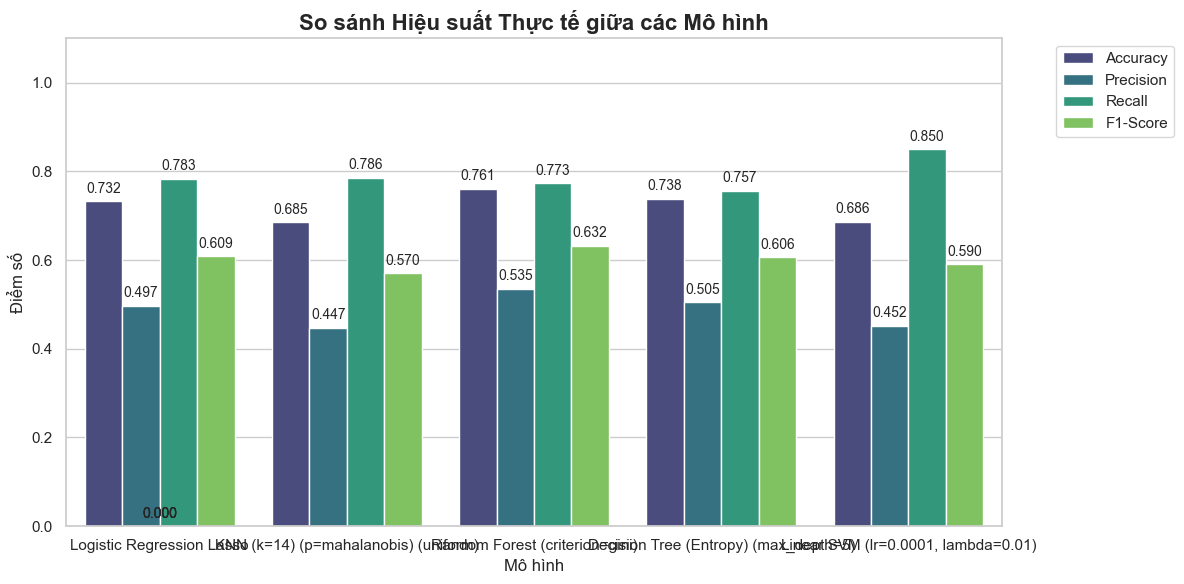

In [26]:
create_comparison_table(best_model_results)

In [5]:
import pickle
with open('results/best_model_results.pkl','rb') as f:
    best_model_results = pickle.load(f)

In [7]:
with open('results/train_test_data.pkl', 'rb') as f:
    X_train_resampled,X_test, y_train_resampled, y_test = pickle.load(f)

Đã lưu kết quả cho Mixed Naive Bayes (alpha=0.01)
Đã lưu kết quả cho Mixed Naive Bayes (alpha=0.1)
Đã lưu kết quả cho Mixed Naive Bayes (alpha=1.0)
Đã lưu kết quả cho Mixed Naive Bayes (alpha=10)
BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Mixed Naive Bayes (alpha=0.01),0.7036,0.4662,0.7941,0.5875
1,Mixed Naive Bayes (alpha=0.1),0.7036,0.4662,0.7941,0.5875
2,Mixed Naive Bayes (alpha=1.0),0.7036,0.4662,0.7941,0.5875
3,Mixed Naive Bayes (alpha=10),0.7036,0.4662,0.7941,0.5875


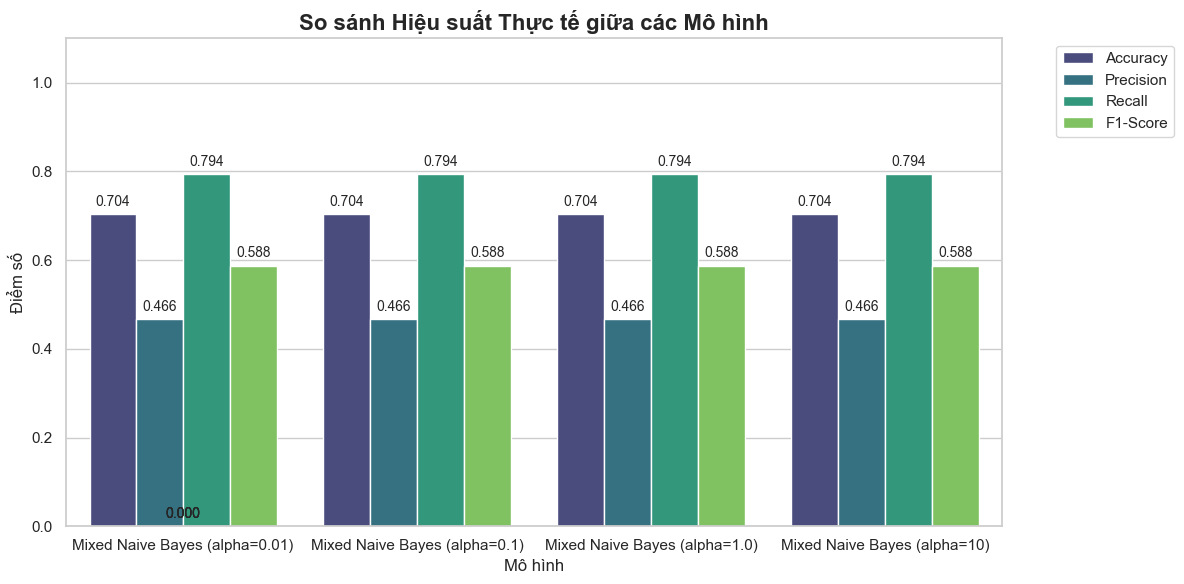

In [10]:
from CustomMixedNB import CustomeMixedNB
NB_model_results = {
    'Mô hình': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}
for alpha in [0.01, 0.1, 1.0, 10]:
    mixed_nb_model = CustomeMixedNB(alpha=1.0)
    mixed_nb_model.fit(X_train_resampled, y_train_resampled)
    y_pred_nb = mixed_nb_model.predict(X_test)
    save_model_results(NB_model_results, f'Mixed Naive Bayes (alpha={alpha})', y_test.values, y_pred_nb)
create_comparison_table(NB_model_results)


In [12]:
with open('results/NB_model_results.pkl', 'wb') as f:
    pickle.dump(NB_model_results, f)

In [11]:
for key in best_model_results:
    best_model_results[key].append(NB_model_results[key][2])

In [13]:
with open('results/best_model_results.pkl', 'wb') as f:
    pickle.dump(best_model_results, f)

BẢNG SO SÁNH HIỆU NĂNG THỰC TẾ:


,Mô hình,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression Lasso,0.7321,0.4975,0.7834,0.6085
1,KNN (k=14) (p=mahalanobis) (uniform),0.6851,0.4475,0.7861,0.5703
2,Random Forest (criterion=gini),0.7612,0.5352,0.7727,0.6324
3,Decision Tree (Entropy) (max_depth=5),0.7385,0.5054,0.7567,0.6060
4,"Linear SVM (lr=0.0001, lambda=0.01)",0.6859,0.4517,0.8503,0.5900
5,Mixed Naive Bayes (alpha=1.0),0.7036,0.4662,0.7941,0.5875


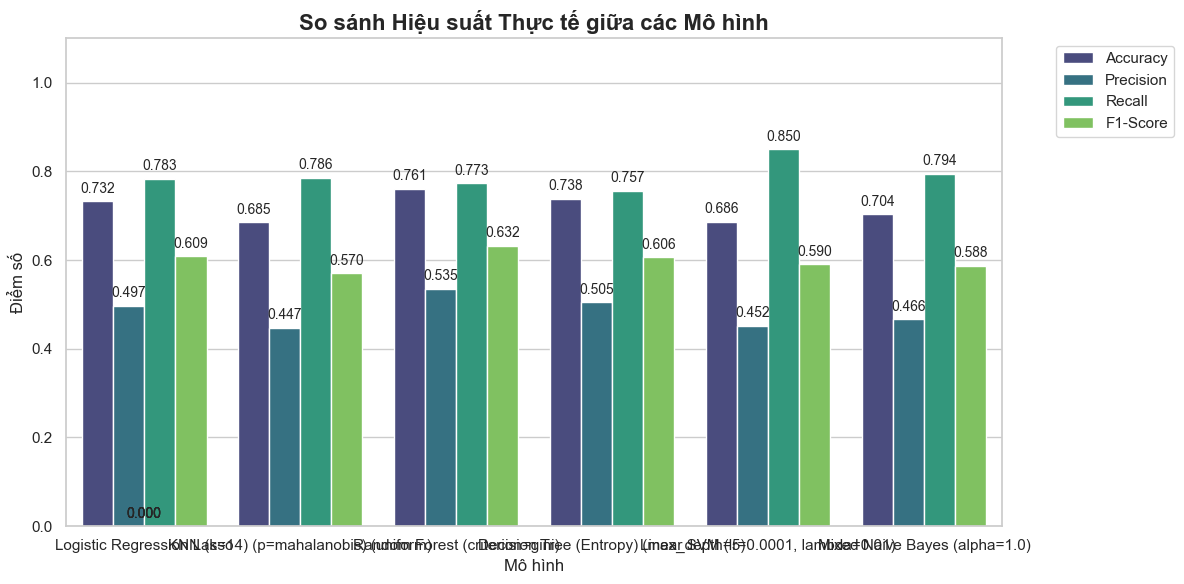

In [14]:
create_comparison_table(best_model_results)